Dataset shape: (65114, 69)
Total records: 65114
Total variables: 69

Column names:
['ABN', 'Charity_Legal_Name', 'Other_Organisation_Names', 'Address_Type', 'Address_Line_1', 'Address_Line_2', 'Address_Line_3', 'Town_City', 'State', 'Postcode', 'Country', 'Charity_Website', 'Registration_Date', 'Date_Organisation_Established', 'Charity_Size', 'Number_of_Responsible_Persons', 'Financial_Year_End', 'Operates_in_ACT', 'Operates_in_NSW', 'Operates_in_NT', 'Operates_in_QLD', 'Operates_in_SA', 'Operates_in_TAS', 'Operates_in_VIC', 'Operates_in_WA', 'Operating_Countries', 'PBI', 'HPC', 'Preventing_or_relieving_suffering_of_animals', 'Advancing_Culture', 'Advancing_Education', 'Advancing_Health', 'Promote_or_oppose_a_change_to_law__government_poll_or_prac', 'Advancing_natual_environment', 'Promoting_or_protecting_human_rights', 'Purposes_beneficial_to_ther_general_public_and_other_analogous', 'Promoting_reconciliation__mutual_respect_and_tolerance', 'Advancing_Religion', 'Advancing_social_or_p

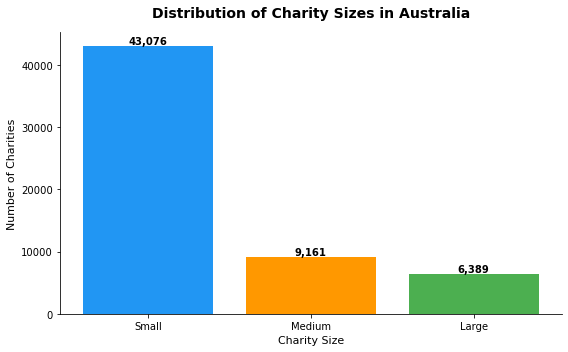

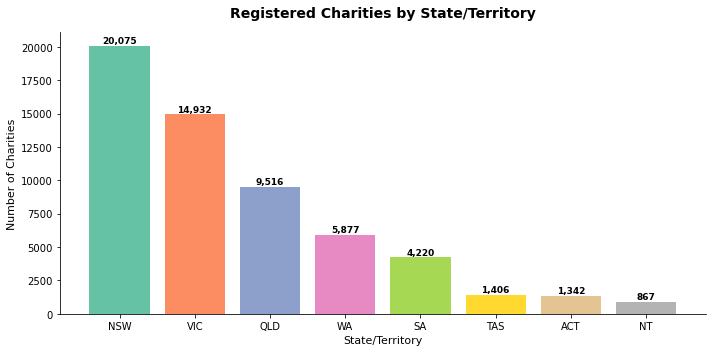

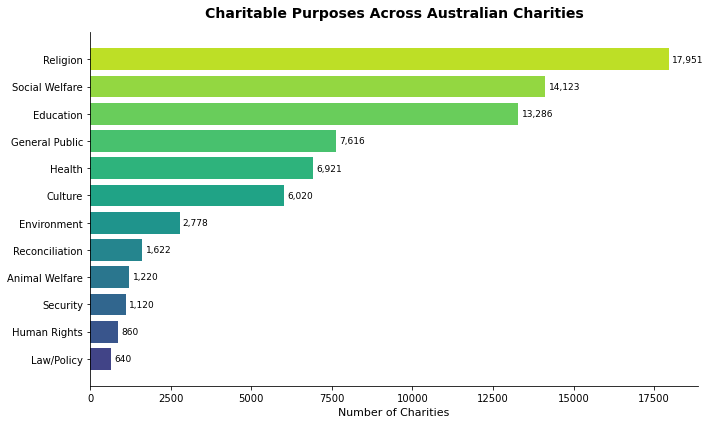

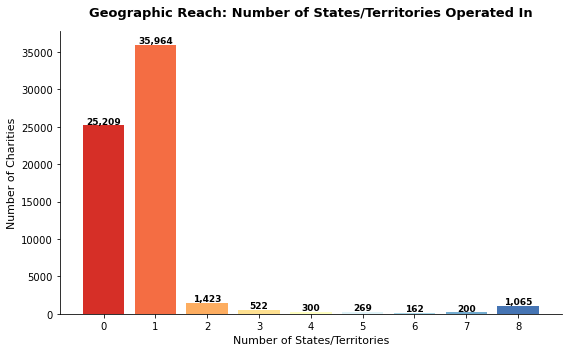

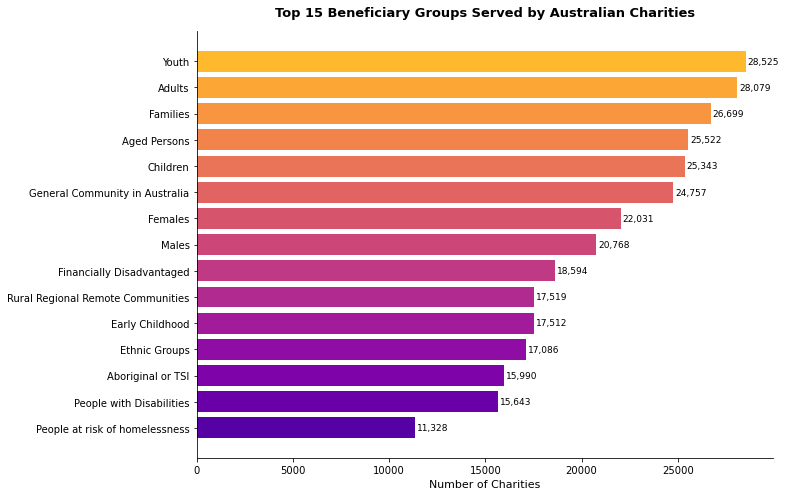


=== NT Overview ===
NT charities: 867
NT % of national total: 1.5%
NT mean responsible persons: 6.5
National mean responsible persons: 5.3


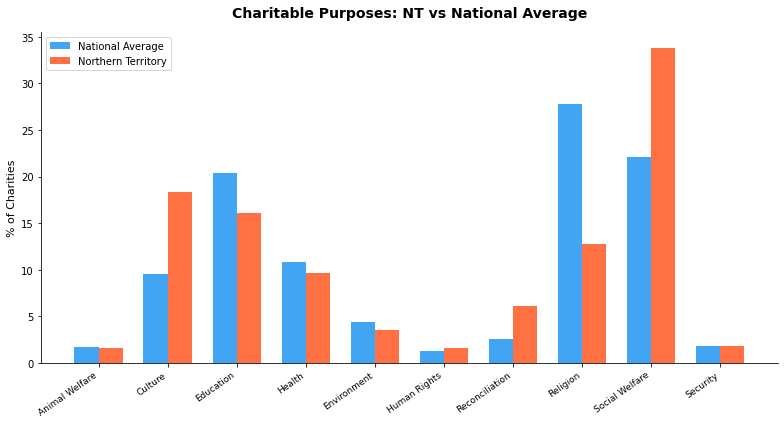

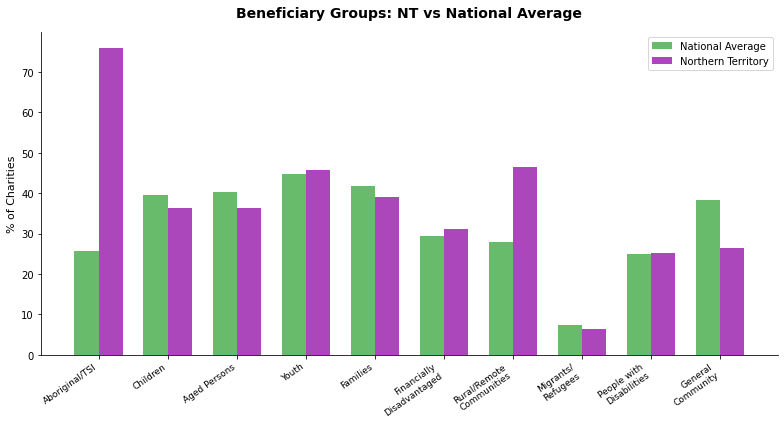

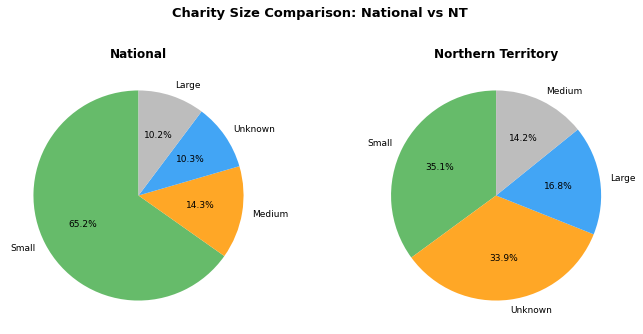


✅ All charts generated successfully!
Files saved: chart1 through chart8


In [2]:
# ==============================================================================
# EDA Analysis — ACNC Charity Register Dataset
# PRT564 Group Project Plan
# Author: Harsh Rastogi - Analysis Lead
# Date: March 2026
# Description: Exploratory Data Analysis including NT-specific insights, size distribution, purpose analysis, and beneficiary group analysis.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ------------------------------------------------------------------------------
# 1. Load and inspect the dataset
# ------------------------------------------------------------------------------
df = pd.read_csv('datadotgov_main.csv', encoding='latin-1', low_memory=False)

print(f"Dataset shape: {df.shape}")
print(f"Total records: {len(df)}")
print(f"Total variables: {len(df.columns)}")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

# ------------------------------------------------------------------------------
# 2. Data Cleaning — Standardise State column
# ------------------------------------------------------------------------------
state_map = {
    'NSW': 'NSW', 'nsw': 'NSW',
    'VIC': 'VIC', 'Vic': 'VIC', 'vic': 'VIC',
    'QLD': 'QLD', 'Qld': 'QLD', 'qld': 'QLD',
    'WA': 'WA', 'Wa': 'WA', 'wa': 'WA',
    'SA': 'SA',
    'TAS': 'TAS', 'Tas': 'TAS',
    'ACT': 'ACT',
    'NT': 'NT'
}
df['State_Clean'] = df['State'].str.strip().map(state_map)

# Count how many states each charity operates in
state_ops = ['Operates_in_ACT', 'Operates_in_NSW', 'Operates_in_NT',
             'Operates_in_QLD', 'Operates_in_SA', 'Operates_in_TAS',
             'Operates_in_VIC', 'Operates_in_WA']
df['Num_States_Operated'] = df[state_ops].apply(lambda x: (x == 'Y').sum(), axis=1)

# ------------------------------------------------------------------------------
# 3. Basic Statistics
# ------------------------------------------------------------------------------
print("\n=== Charity Size Distribution ===")
print(df['Charity_Size'].value_counts(dropna=False))

print("\n=== State Distribution ===")
print(df['State_Clean'].value_counts(dropna=False))

print("\n=== Responsible Persons Stats ===")
print(df['Number_of_Responsible_Persons'].describe())

print("\n=== Missing Values (top 10) ===")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# ------------------------------------------------------------------------------
# 4. Chart Styling Setup — consistent look across all charts
# ------------------------------------------------------------------------------
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

def clean_axes(ax):
    """Remove top and right spines for a cleaner look"""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ------------------------------------------------------------------------------
# 5. Chart 1 — Charity Size Distribution
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
sizes = df['Charity_Size'].value_counts()
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9E9E9E']
bars = ax.bar(sizes.index, sizes.values, color=colors[:len(sizes)])

ax.set_title('Distribution of Charity Sizes in Australia',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Charity Size', fontsize=11)
ax.set_ylabel('Number of Charities', fontsize=11)

# Add value labels on top of each bar
for bar, val in zip(bars, sizes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

clean_axes(ax)
plt.tight_layout()
plt.savefig('chart1_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 6. Chart 2 — Charities by State/Territory
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
state_counts = df['State_Clean'].value_counts().dropna()
colors2 = plt.cm.Set2(np.linspace(0, 1, len(state_counts)))
bars = ax.bar(state_counts.index, state_counts.values, color=colors2)

ax.set_title('Registered Charities by State/Territory',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('State/Territory', fontsize=11)
ax.set_ylabel('Number of Charities', fontsize=11)

for bar, val in zip(bars, state_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')

clean_axes(ax)
plt.tight_layout()
plt.savefig('chart2_state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 7. Chart 3 — Charitable Purposes Distribution
# ------------------------------------------------------------------------------
purpose_columns = {
    'Religion': 'Advancing_Religion',
    'Social Welfare': 'Advancing_social_or_public_welfare',
    'Education': 'Advancing_Education',
    'General Public': 'Purposes_beneficial_to_ther_general_public_and_other_analogous',
    'Health': 'Advancing_Health',
    'Culture': 'Advancing_Culture',
    'Environment': 'Advancing_natual_environment',
    'Reconciliation': 'Promoting_reconciliation__mutual_respect_and_tolerance',
    'Animal Welfare': 'Preventing_or_relieving_suffering_of_animals',
    'Security': 'Advancing_security_or_safety_of_Australia_or_Australian_public',
    'Human Rights': 'Promoting_or_protecting_human_rights',
    'Law/Policy': 'Promote_or_oppose_a_change_to_law__government_poll_or_prac',
}

purposes = {label: (df[col] == 'Y').sum() for label, col in purpose_columns.items()}
sorted_purposes = dict(sorted(purposes.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(10, 6))
colors3 = plt.cm.viridis(np.linspace(0.2, 0.9, len(sorted_purposes)))
bars = ax.barh(list(sorted_purposes.keys())[::-1],
               list(sorted_purposes.values())[::-1], color=colors3)

ax.set_title('Charitable Purposes Across Australian Charities',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Charities', fontsize=11)

for bar, val in zip(bars, list(sorted_purposes.values())[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

clean_axes(ax)
plt.tight_layout()
plt.savefig('chart3_purposes.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 8. Chart 4 — Geographic Reach
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ns = df['Num_States_Operated'].value_counts().sort_index()
colors4 = plt.cm.RdYlBu(np.linspace(0.1, 0.9, len(ns)))
bars = ax.bar(ns.index.astype(str), ns.values, color=colors4)

ax.set_title('Geographic Reach: Number of States/Territories Operated In',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of States/Territories', fontsize=11)
ax.set_ylabel('Number of Charities', fontsize=11)

for bar, val in zip(bars, ns.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')

clean_axes(ax)
plt.tight_layout()
plt.savefig('chart4_geographic_reach.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 9. Chart 5 — Top 15 Beneficiary Groups
# ------------------------------------------------------------------------------
beneficiary_columns = [
    'Aboriginal_or_TSI', 'Adults', 'Aged_Persons', 'Children',
    'Communities_Overseas', 'Early_Childhood', 'Ethnic_Groups',
    'Families', 'Females', 'Financially_Disadvantaged',
    'General_Community_in_Australia', 'Males',
    'Migrants_Refugees_or_Asylum_Seekers', 'People_at_risk_of_homelessness',
    'People_with_Chronic_Illness', 'People_with_Disabilities',
    'Rural_Regional_Remote_Communities', 'Unemployed_Person',
    'Veterans_or_their_families', 'Youth'
]

ben_counts = {}
for col in beneficiary_columns:
    label = col.replace('_', ' ')
    ben_counts[label] = (df[col] == 'Y').sum()

# Take top 15 only
sorted_ben = dict(sorted(ben_counts.items(), key=lambda x: x[1], reverse=True)[:15])

fig, ax = plt.subplots(figsize=(11, 7))
colors5 = plt.cm.plasma(np.linspace(0.15, 0.85, len(sorted_ben)))
bars = ax.barh(list(sorted_ben.keys())[::-1],
               list(sorted_ben.values())[::-1], color=colors5)

ax.set_title('Top 15 Beneficiary Groups Served by Australian Charities',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Charities', fontsize=11)

for bar, val in zip(bars, list(sorted_ben.values())[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

clean_axes(ax)
plt.tight_layout()
plt.savefig('chart5_beneficiaries.png', dpi=150, bbox_inches='tight')
plt.show()

# ==============================================================================
# NT-SPECIFIC ANALYSIS
# ==============================================================================

# ------------------------------------------------------------------------------
# 10. Filter NT vs National data
# ------------------------------------------------------------------------------
nt = df[df['State_Clean'] == 'NT']
national = df[df['State_Clean'].notna()]

print(f"\n=== NT Overview ===")
print(f"NT charities: {len(nt)}")
print(f"NT % of national total: {len(nt)/len(national)*100:.1f}%")
print(f"NT mean responsible persons: {nt['Number_of_Responsible_Persons'].mean():.1f}")
print(f"National mean responsible persons: {national['Number_of_Responsible_Persons'].mean():.1f}")

# ------------------------------------------------------------------------------
# 11. Chart 6 — NT vs National: Charitable Purposes
# ------------------------------------------------------------------------------
purpose_labels = ['Animal Welfare', 'Culture', 'Education', 'Health',
                  'Environment', 'Human Rights', 'Reconciliation',
                  'Religion', 'Social Welfare', 'Security']
purpose_cols = [
    'Preventing_or_relieving_suffering_of_animals', 'Advancing_Culture',
    'Advancing_Education', 'Advancing_Health', 'Advancing_natual_environment',
    'Promoting_or_protecting_human_rights',
    'Promoting_reconciliation__mutual_respect_and_tolerance',
    'Advancing_Religion', 'Advancing_social_or_public_welfare',
    'Advancing_security_or_safety_of_Australia_or_Australian_public'
]

nt_pct = [(nt[col] == 'Y').sum() / len(nt) * 100 for col in purpose_cols]
nat_pct = [(national[col] == 'Y').sum() / len(national) * 100 for col in purpose_cols]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(purpose_labels))
width = 0.35

ax.bar(x - width/2, nat_pct, width, label='National Average', color='#2196F3', alpha=0.85)
ax.bar(x + width/2, nt_pct, width, label='Northern Territory', color='#FF5722', alpha=0.85)

ax.set_title('Charitable Purposes: NT vs National Average',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('% of Charities', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(purpose_labels, rotation=35, ha='right', fontsize=9)
ax.legend(fontsize=10)
clean_axes(ax)
plt.tight_layout()
plt.savefig('chart6_nt_vs_national_purposes.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 12. Chart 7 — NT vs National: Beneficiary Groups
# ------------------------------------------------------------------------------
bene_cols = ['Aboriginal_or_TSI', 'Children', 'Aged_Persons', 'Youth',
             'Families', 'Financially_Disadvantaged',
             'Rural_Regional_Remote_Communities',
             'Migrants_Refugees_or_Asylum_Seekers',
             'People_with_Disabilities', 'General_Community_in_Australia']
bene_labels = ['Aboriginal/TSI', 'Children', 'Aged Persons', 'Youth',
               'Families', 'Financially\nDisadvantaged',
               'Rural/Remote\nCommunities', 'Migrants/\nRefugees',
               'People with\nDisabilities', 'General\nCommunity']

nt_bpct = [(nt[col] == 'Y').sum() / len(nt) * 100 for col in bene_cols]
nat_bpct = [(national[col] == 'Y').sum() / len(national) * 100 for col in bene_cols]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(bene_labels))

ax.bar(x - width/2, nat_bpct, width, label='National Average', color='#4CAF50', alpha=0.85)
ax.bar(x + width/2, nt_bpct, width, label='Northern Territory', color='#9C27B0', alpha=0.85)

ax.set_title('Beneficiary Groups: NT vs National Average',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('% of Charities', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(bene_labels, rotation=35, ha='right', fontsize=9)
ax.legend(fontsize=10)
clean_axes(ax)
plt.tight_layout()
plt.savefig('chart7_nt_vs_national_beneficiaries.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 13. Chart 8 — Size Comparison: NT vs National (Pie Charts)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
colors_pie = ['#66BB6A', '#FFA726', '#42A5F5', '#BDBDBD']

for ax_i, (data_slice, title) in enumerate([
    (national, 'National'),
    (nt, 'Northern Territory')
]):
    size_counts = data_slice['Charity_Size'].value_counts(dropna=False)
    labels = [str(l) if pd.notna(l) else 'Unknown' for l in size_counts.index]
    axes[ax_i].pie(size_counts.values, labels=labels, autopct='%1.1f%%',
                   colors=colors_pie[:len(size_counts)], startangle=90,
                   textprops={'fontsize': 9})
    axes[ax_i].set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Charity Size Comparison: National vs NT',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart8_nt_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All charts generated successfully!")
print("Files saved: chart1 through chart8")